# 문제 2 — 회전 행렬 구현과 합성 순서 검증

축별 회전 행렬 `rot_x`, `rot_y`, `rot_z` 를 직접 구현하고,
회전이 갖는 성질들을 행렬과 그림 양쪽으로 확인합니다.

## 이 노트북에서 해야 할 일

| # | 할 일 | 구현할 함수 |
|---|---|---|
| 2-1 | 축별 회전 행렬을 만들고 `rot_z(22.5도)` 가 (1,0,0) 을 어디로 보내는지 확인 | `rot_x`, `rot_y`, `rot_z` |
| 2-2 | 세 축 회전을 **Matplotlib 3D 로 그려** 회전축 성분이 보존됨을 눈으로 확인 (그림 코드 제공) | — |
| 2-3 | **합성 순서가 다르면 결과가 달라짐**을 행렬과 **나란히 그린 3D 그림**으로 비교 (그림 코드 제공) | — |
| 2-4 | 세 회전 행렬의 행렬식과 반사 행렬 `diag(1,-1,1)` 의 행렬식을 비교하고 **왜 1 이어야 하는지** 설명 | (문제 1 의 `det`) |
| 2-5 | 문제 1 의 `skew` 로 **로드리게스 공식**을 구현하고 `rot_z` 와 일치하는지 검증 | `rodrigues` |

> 각도는 **라디안**으로 받습니다. 도 단위는 `np.deg2rad` 로 바꿔 넣으세요.
> 순서 의존성 비교 그림은 **반드시 포함**되어야 합니다.
> `# --- 검증 ---` 셀과 3D 그림 셀은 제공된 코드입니다. 수정하지 말고 참조하는 변수 이름을 맞춰 주세요.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.rotation import rodrigues, rot_x, rot_y, rot_z
from src.vectors import det, skew          # 문제 1 에서 만든 함수를 재사용

rng = np.random.default_rng(42)
np.set_printoptions(precision=6, suppress=True)

# 한글 라벨이 깨지지 않도록 폰트 지정 (Windows 기준, 없으면 기본 폰트로 fallback)
for _f in ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]:
    if _f in {f.name for f in __import__("matplotlib").font_manager.fontManager.ttflist}:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False


def check(label, condition):
    tag = "PASS" if condition else "FAIL"
    print("[" + tag + "] " + label)
    return bool(condition)


# --- 그림 헬퍼 (그대로 쓰면 됩니다) -----------------------------------------

def draw_frame(ax, R=np.eye(3), origin=(0, 0, 0), scale=1.0, alpha=1.0, labels=None):
    """회전 행렬 R 의 세 열을 x(빨강)·y(초록)·z(파랑) 축으로 그린다."""
    origin = np.asarray(origin, dtype=float)
    colors = ["r", "g", "b"]
    names = labels if labels else ["x", "y", "z"]
    for i in range(3):
        v = R[:, i] * scale
        ax.quiver(*origin, *v, color=colors[i], alpha=alpha, arrow_length_ratio=0.15)
        ax.text(*(origin + v * 1.12), names[i], color=colors[i], fontsize=9)


def setup_axes(ax, title, lim=1.3):
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_zlim(-lim, lim)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_title(title, fontsize=10)
    ax.set_box_aspect([1, 1, 1])


print("준비 완료")

준비 완료


## 2-1. 축별 회전 행렬과 `rot_z(22.5도)` 검증

오른손 좌표계에서 각 축 회전 행렬은 다음과 같습니다.

$$R_x(\theta)=\begin{bmatrix}1&0&0\\0&\cos\theta&-\sin\theta\\0&\sin\theta&\cos\theta\end{bmatrix},\quad
R_y(\theta)=\begin{bmatrix}\cos\theta&0&\sin\theta\\0&1&0\\-\sin\theta&0&\cos\theta\end{bmatrix},\quad
R_z(\theta)=\begin{bmatrix}\cos\theta&-\sin\theta&0\\\sin\theta&\cos\theta&0\\0&0&1\end{bmatrix}$$

$R_y$ 만 부호 배치가 뒤집혀 보입니다. 오른손 규칙에서 y축 회전이 어느 축에서
어느 축으로 도는지 생각해 보면 이유를 설명할 수 있습니다.

**할 일** — 세 함수를 구현하고, $R_z(22.5^\circ)$ 를 $(1,0,0)$ 에 적용한 결과를 확인하세요.
결과는 $(\cos 22.5^\circ,\ \sin 22.5^\circ,\ 0)$ 이어야 합니다. 이 값을 **먼저 손으로** 구해 두세요
($\cos 22.5^\circ = \tfrac{\sqrt{2+\sqrt2}}{2}$).

In [2]:
ANG = np.deg2rad(22.5)
p = np.array([1.0, 0.0, 0.0])

Rz = rot_z(ANG)
p_rot = Rz @ p

Rx = rot_x(ANG)
Ry = rot_y(ANG)

expected = np.array([np.sqrt(2 + np.sqrt(2)) / 2, np.sqrt(2 - np.sqrt(2)) / 2, 0.0])

print("Rz =\n", Rz)
print("Rx =\n", Rx)
print("Ry =\n", Ry)
print("p_rot =", p_rot)
print("expected =", expected)

Rz =
 [[ 0.92388  -0.382683  0.      ]
 [ 0.382683  0.92388   0.      ]
 [ 0.        0.        1.      ]]
Rx =
 [[ 1.        0.        0.      ]
 [ 0.        0.92388  -0.382683]
 [ 0.        0.382683  0.92388 ]]
Ry =
 [[ 0.92388   0.        0.382683]
 [ 0.        1.        0.      ]
 [-0.382683  0.        0.92388 ]]
p_rot = [0.92388  0.382683 0.      ]
expected = [0.92388  0.382683 0.      ]


In [3]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("rot_z(22.5도) @ (1,0,0) == (cos22.5, sin22.5, 0)", np.allclose(p_rot, expected))
ok &= check("손계산 기대값이 (0.923880, 0.382683, 0)", np.allclose(expected, [0.9238795, 0.3826834, 0.0]))
ok &= check("rot_x(22.5도) @ (0,1,0) == (0, cos, sin)",
            np.allclose(rot_x(ANG) @ [0, 1, 0], [0, np.cos(ANG), np.sin(ANG)]))
ok &= check("rot_y(22.5도) @ (0,0,1) == (sin, 0, cos)",
            np.allclose(rot_y(ANG) @ [0, 0, 1], [np.sin(ANG), 0, np.cos(ANG)]))
ok &= check("rot_y(22.5도) @ (1,0,0) == (cos, 0, -sin)  (y축은 z->x 방향으로 돈다)",
            np.allclose(rot_y(ANG) @ [1, 0, 0], [np.cos(ANG), 0, -np.sin(ANG)]))
ok &= check("0도 회전은 단위행렬", np.allclose(rot_z(0.0), np.eye(3)))
ok &= check("R(theta) @ R(-theta) == I", np.allclose(rot_z(0.7) @ rot_z(-0.7), np.eye(3)))
ok &= check("네 번 돌리면 90도: rot_z(22.5)^4 == rot_z(90)",
            np.allclose(np.linalg.matrix_power(rot_z(ANG), 4), rot_z(np.pi / 2)))
ok &= check("회전은 길이를 보존", np.isclose(np.linalg.norm(p_rot), np.linalg.norm(p)))
print("\n2-1 전체 통과:", ok)

[PASS] rot_z(22.5도) @ (1,0,0) == (cos22.5, sin22.5, 0)
[PASS] 손계산 기대값이 (0.923880, 0.382683, 0)
[PASS] rot_x(22.5도) @ (0,1,0) == (0, cos, sin)
[PASS] rot_y(22.5도) @ (0,0,1) == (sin, 0, cos)
[PASS] rot_y(22.5도) @ (1,0,0) == (cos, 0, -sin)  (y축은 z->x 방향으로 돈다)
[PASS] 0도 회전은 단위행렬
[PASS] R(theta) @ R(-theta) == I
[PASS] 네 번 돌리면 90도: rot_z(22.5)^4 == rot_z(90)
[PASS] 회전은 길이를 보존

2-1 전체 통과: True


## 2-2. 축별 회전 3D 시각화 — 회전축 성분은 보존된다

임의의 점 하나를 각 축 기준으로 0 ~ 360도 돌리면 궤적이 어떤 모양이 되는지,
그리고 **어떤 성분이 변하지 않는지** 그림으로 확인합니다.

아래 그림 셀은 **제공된 코드**입니다. `rot_x/y/z` 만 올바르면 그대로 동작합니다.
그림을 보고 마크다운에 관찰 내용을 적으세요.

### 관찰

- 궤적의 모양: 각 축 회전에서 궤적은 회전축에 수직인 원이다.
- 보존되는 성분과 그 이유 (행렬의 어느 행/열 때문인지): 회전축에 해당하는 행이 표준기저벡터이므로 그 성분만 다른 성분과 섞이지 않고 그대로 유지되고, 같은 위치의 열이 표준기저벡터이므로 회전축 벡터 자체가 고유값 1의 고유벡터가 되어 변하지 않는다.

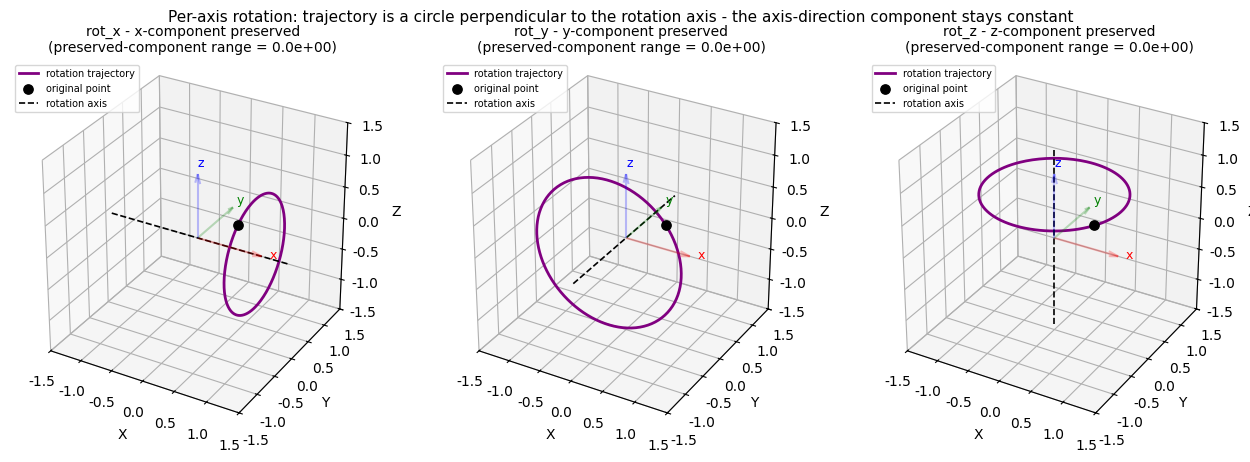

In [4]:
# --- 3D 그림 (제공 코드) ---
p0 = np.array([0.9, -0.5, 0.7])
angles = np.linspace(0, 2 * np.pi, 200)

fig = plt.figure(figsize=(13, 4.4))
info = []       # (이름, 보존 성분의 변화폭) — 검증 셀에서 사용
for k, (name, maker, axis_vec, keep) in enumerate([
    ("rot_x - x-component preserved", rot_x, [1, 0, 0], 0),
    ("rot_y - y-component preserved", rot_y, [0, 1, 0], 1),
    ("rot_z - z-component preserved", rot_z, [0, 0, 1], 2),
]):
    traj = np.array([maker(t) @ p0 for t in angles])
    spread = traj[:, keep].max() - traj[:, keep].min()
    info.append((name, spread))

    ax = fig.add_subplot(1, 3, k + 1, projection="3d")
    setup_axes(ax, name + "\n(preserved-component range = {:.1e})".format(spread), lim=1.5)
    draw_frame(ax, scale=1.0, alpha=0.25)
    ax.plot(traj[:, 0], traj[:, 1], traj[:, 2], color="purple", lw=2, label="rotation trajectory")
    ax.scatter(*p0, color="k", s=45, label="original point")
    av = np.array(axis_vec, dtype=float) * 1.4
    ax.plot([-av[0], av[0]], [-av[1], av[1]], [-av[2], av[2]], "k--", lw=1.2, label="rotation axis")
    ax.legend(fontsize=7, loc="upper left")

fig.suptitle("Per-axis rotation: trajectory is a circle perpendicular to the rotation axis - the axis-direction component stays constant", fontsize=11)
fig.tight_layout()
plt.show()

In [5]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = True
for name, spread in info:
    ok &= check(name + " : 보존 성분 변화폭 {:.2e} < 1e-12".format(spread), spread < 1e-12)

traj = np.array([rot_z(t) @ p0 for t in angles])
radii = np.linalg.norm(traj, axis=1)
ok &= check("회전 궤적의 모든 점이 원점에서 등거리", np.allclose(radii, np.linalg.norm(p0)))
ok &= check("z축 회전 궤적의 반지름은 sqrt(x0^2 + y0^2)",
            np.allclose(np.linalg.norm(traj[:, :2], axis=1), np.hypot(p0[0], p0[1])))
print("\n2-2 전체 통과:", ok)

[PASS] rot_x - x-component preserved : 보존 성분 변화폭 0.00e+00 < 1e-12
[PASS] rot_y - y-component preserved : 보존 성분 변화폭 0.00e+00 < 1e-12
[PASS] rot_z - z-component preserved : 보존 성분 변화폭 0.00e+00 < 1e-12
[PASS] 회전 궤적의 모든 점이 원점에서 등거리
[PASS] z축 회전 궤적의 반지름은 sqrt(x0^2 + y0^2)

2-2 전체 통과: True


## 2-3. 합성 순서가 다르면 결과가 다르다

행렬 곱은 교환법칙이 성립하지 않습니다: $R_y R_z \neq R_z R_y$.

표기 약속: $R_y R_z \mathbf{p}$ 는 "**$R_z$ 를 먼저**, 그다음 $R_y$" 라는 뜻입니다
(오른쪽 것이 먼저 적용됩니다).

**할 일**

- y축 22.5도와 z축 67.5도를 두 순서로 합성해 결과 행렬 A, B 를 만들고 차이를 출력하세요.
- 아래 3분할 3D 그림(제공)으로 같은 초기 자세가 두 순서로 어떻게 다르게 끝나는지 비교하세요.
- 왜 물리적으로 당연한 결과인지 아래에 적으세요.

### 순서가 결과를 바꾸는 이유

- 행렬 곱은 교환법칙이 성립하지 않는다. 먼저 적용한 회전이 다음 회전의 회전축 자체를 함께 돌려 놓기 때문에, 어느 것을 먼저 적용하느냐에 따라 최종 자세가 달라진다.


In [6]:
ang_y = np.deg2rad(22.5)
ang_z = np.deg2rad(67.5)
test_p = np.array([1.0, 0.0, 0.0])

A = rot_y(ang_y) @ rot_z(ang_z)   # z 먼저, 그 다음 y
B = rot_z(ang_z) @ rot_y(ang_y)   # y 먼저, 그 다음 z

print("A (Ry @ Rz) =\n", A)
print("B (Rz @ Ry) =\n", B)
print("최대 성분 차이 |A-B| =", np.max(np.abs(A - B)))
print("A @ test_p =", A @ test_p)
print("B @ test_p =", B @ test_p)

A (Ry @ Rz) =
 [[ 0.353553 -0.853553  0.382683]
 [ 0.92388   0.382683  0.      ]
 [-0.146447  0.353553  0.92388 ]]
B (Rz @ Ry) =
 [[ 0.353553 -0.92388   0.146447]
 [ 0.853553  0.382683  0.353553]
 [-0.382683  0.        0.92388 ]]
최대 성분 차이 |A-B| = 0.3535533905932738
A @ test_p = [ 0.353553  0.92388  -0.146447]
B @ test_p = [ 0.353553  0.853553 -0.382683]


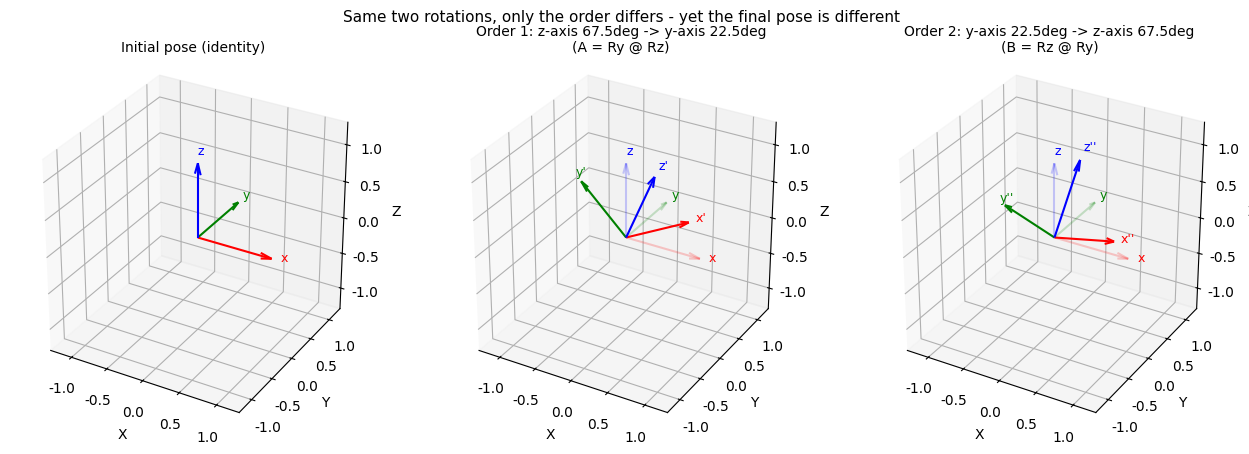

In [7]:
# --- 3D 그림 (제공 코드) ---
fig = plt.figure(figsize=(13, 4.4))

ax = fig.add_subplot(1, 3, 1, projection="3d")
setup_axes(ax, "Initial pose (identity)")
draw_frame(ax, np.eye(3))

ax = fig.add_subplot(1, 3, 2, projection="3d")
setup_axes(ax, "Order 1: z-axis 67.5deg -> y-axis 22.5deg\n(A = Ry @ Rz)")
draw_frame(ax, np.eye(3), alpha=0.2)
draw_frame(ax, A, labels=["x'", "y'", "z'"])

ax = fig.add_subplot(1, 3, 3, projection="3d")
setup_axes(ax, "Order 2: y-axis 22.5deg -> z-axis 67.5deg\n(B = Rz @ Ry)")
draw_frame(ax, np.eye(3), alpha=0.2)
draw_frame(ax, B, labels=["x''", "y''", "z''"])

fig.suptitle("Same two rotations, only the order differs - yet the final pose is different", fontsize=11)
fig.tight_layout()
plt.show()

In [8]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("두 합성 결과 행렬이 다르다", not np.allclose(A, B))
ok &= check("A 의 정의가 맞다 (Ry @ Rz)", np.allclose(A, rot_y(ang_y) @ rot_z(ang_z)))
ok &= check("B 의 정의가 맞다 (Rz @ Ry)", np.allclose(B, rot_z(ang_z) @ rot_y(ang_y)))
ok &= check("같은 축끼리는 순서를 바꿔도 같다 (교환 가능)",
            np.allclose(rot_z(0.3) @ rot_z(0.9), rot_z(0.9) @ rot_z(0.3)))
ok &= check("각도가 0 이면 순서가 무의미", np.allclose(rot_y(0.0) @ rot_z(0.5), rot_z(0.5) @ rot_y(0.0)))
ok &= check("두 결과 모두 회전행렬 (det = 1)",
            np.isclose(det(A), 1.0) and np.isclose(det(B), 1.0))
ok &= check("A 와 B 는 서로 다른 곳으로 (1,0,0) 을 보낸다",
            not np.allclose(A @ test_p, B @ test_p))
ok &= check("B 는 (1,0,0) 의 z 성분을 바꾸지 않는다 (y 회전 후 z 회전이라)",
            np.isclose((B @ test_p)[2], -np.sin(ang_y)))
print("\n2-3 전체 통과:", ok)

[PASS] 두 합성 결과 행렬이 다르다
[PASS] A 의 정의가 맞다 (Ry @ Rz)
[PASS] B 의 정의가 맞다 (Rz @ Ry)
[PASS] 같은 축끼리는 순서를 바꿔도 같다 (교환 가능)
[PASS] 각도가 0 이면 순서가 무의미
[PASS] 두 결과 모두 회전행렬 (det = 1)
[PASS] A 와 B 는 서로 다른 곳으로 (1,0,0) 을 보낸다
[PASS] B 는 (1,0,0) 의 z 성분을 바꾸지 않는다 (y 회전 후 z 회전이라)

2-3 전체 통과: True


## 2-4. 행렬식이 1 이어야 하는 이유 — 회전 vs 반사

직교행렬($R^{\mathsf{T}}R=I$)의 행렬식은 $\pm 1$ 뿐입니다.
$\det(R^{\mathsf{T}}R)=\det(R)^2=\det(I)=1$ 이기 때문입니다.

그렇다면 $\det = -1$ 인 직교행렬은 무엇일까요?
대각성분이 $(1,-1,1)$ 인 행렬을 놓고 다음을 직접 확인해 보세요.

- 직교성($S^{\mathsf{T}}S=I$)은 만족하는가
- 행렬식은 얼마인가
- $\mathbf{x}' \times \mathbf{y}' = \mathbf{z}'$ (오른손 규칙)이 유지되는가

세 질문의 답을 모으면 "왜 직교만으로는 부족하고 $\det=+1$ 까지 요구하는가" 가 나옵니다.
로봇 자세에 $\det=-1$ 행렬이 들어가면 실제로 무슨 일이 벌어질지도 함께 적으세요.

### 행렬식이 1 이어야 하는 이유

- 회전 행렬 세 개의 행렬식: `1.0, 1.0, 1.0 ` / 반사 행렬의 행렬식: `-1.0`
- 차이의 의미: 직교행렬(R^T R = I)의 행렬식은 항상 ±1이다. det=+1인 직교행렬은 오른손 좌표계를 그대로 유지하는 순수 회전(x'×y'=z' 성립)이고, det=-1인 직교행렬은 반사(거울상)가 섞여 있어 오른손 규칙이 깨진다(x'×y'≠z').
- 로봇에서의 영향: 로봇 팔의 링크 자세, 카메라 좌표계 변환 등에서 회전 행렬은 항상 det=+1이어야 한다. 만약 계산 과정에서 부호 실수나 축 정의 오류로 det=-1인 행렬(반사)이 섞여 들어가면, 좌표계의 손대칭(handedness)이 뒤집혀서 팔의 관절이 실제로는 존재할 수 없는 뒤집힌 방향으로 계산되거나, 순기구학/역기구학 결과가 물리적으로 불가능한 자세(예: 관절이 반대로 꺾인 자세)를 내놓게 된다.

In [9]:
S = np.diag([1.0, -1.0, 1.0])     # y 를 뒤집는 반사 행렬
rows = [("rot_x(0.7)", rot_x(0.7)), ("rot_y(1.2)", rot_y(1.2)),
        ("rot_z(-0.4)", rot_z(-0.4)), ("반사 diag(1,-1,1)", S)]

print(f"{'행렬':18s} {'det':>10s} {'직교오차':>12s} {'x1 x y1 == z1':>14s}")
for name, Mx in rows:
    d = det(Mx)
    orth_err = np.max(np.abs(Mx.T @ Mx - np.eye(3)))
    rh_rule = np.allclose(np.cross(Mx[:, 0], Mx[:, 1]), Mx[:, 2])
    print(f"{name:18s} {d:10.4f} {orth_err:12.2e} {str(rh_rule):>14s}")

행렬                        det         직교오차  x1 x y1 == z1
rot_x(0.7)             1.0000     2.08e-17           True
rot_y(1.2)             1.0000     1.11e-16           True
rot_z(-0.4)            1.0000     2.13e-17           True
반사 diag(1,-1,1)       -1.0000     0.00e+00          False


In [10]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("세 회전 행렬의 행렬식이 모두 1",
           all(np.isclose(det(m(t)), 1.0) for m, t in [(rot_x, 0.7), (rot_y, 1.2), (rot_z, -0.4)]))
ok &= check("반사 행렬의 행렬식은 -1", np.isclose(det(S), -1.0))
ok &= check("반사 행렬도 직교이긴 하다", np.allclose(S.T @ S, np.eye(3)))
ok &= check("회전은 오른손 규칙 보존 (x' x y' == z')",
            np.allclose(np.cross(rot_y(1.2)[:, 0], rot_y(1.2)[:, 1]), rot_y(1.2)[:, 2]))
ok &= check("반사는 오른손 규칙을 깬다",
            not np.allclose(np.cross(S[:, 0], S[:, 1]), S[:, 2]))
ok &= check("반사 뒤에 회전을 곱해도 det 는 -1 (회전으로 되돌릴 수 없다)",
            np.isclose(det(rot_z(0.5) @ S), -1.0))
ok &= check("무작위 회전 100개의 det 가 모두 1",
            all(np.isclose(det(rot_z(t1) @ rot_y(t2) @ rot_x(t3)), 1.0)
                for t1, t2, t3 in rng.uniform(-np.pi, np.pi, (100, 3))))
print("\n2-4 전체 통과:", ok)

[PASS] 세 회전 행렬의 행렬식이 모두 1
[PASS] 반사 행렬의 행렬식은 -1
[PASS] 반사 행렬도 직교이긴 하다
[PASS] 회전은 오른손 규칙 보존 (x' x y' == z')
[PASS] 반사는 오른손 규칙을 깬다
[PASS] 반사 뒤에 회전을 곱해도 det 는 -1 (회전으로 되돌릴 수 없다)
[PASS] 무작위 회전 100개의 det 가 모두 1

2-4 전체 통과: True


## 2-5. 로드리게스 공식 — `skew` 로 임의 축 회전

단위 축 $\mathbf{k}$ 를 중심으로 $\theta$ 만큼 도는 회전은

$$R = I + \sin\theta\,[\mathbf{k}]_\times + (1-\cos\theta)\,[\mathbf{k}]_\times^2$$

로 쓸 수 있습니다. 문제 1 에서 만든 `skew` 가 그대로 들어갑니다.
축을 $\mathbf{k}=(0,0,1)$ 로 두면 `rot_z` 와 정확히 같아야 합니다.

**할 일** — `src/rotation.py` 의 `rodrigues` 를 구현하고,
z축·임의 축 두 경우를 확인하세요. 축이 회전 후에도 그대로인지도 봅니다.

In [11]:
theta = np.deg2rad(52.5)
k_raw = np.array([2.0, -1.0, 1.5])        # 정규화되지 않은 임의 축

R_rod_z = rodrigues([0, 0, 1], theta)
print("R_rod_z =\n", R_rod_z)
print("rot_z(theta) =\n", rot_z(theta))

k = k_raw / np.sqrt(k_raw @ k_raw)
R_arb = rodrigues(k, theta)
print("k (정규화됨) =", k)
print("R_arb =\n", R_arb)
print("R_arb @ k =", R_arb @ k, " (k 와 같아야 함)")

K = skew(k)
manual = np.eye(3) + np.sin(theta) * K + (1 - np.cos(theta)) * (K @ K)
print("manual == R_arb ?", np.allclose(manual, R_arb))

R_rod_z =
 [[ 0.608761 -0.793353  0.      ]
 [ 0.793353  0.608761  0.      ]
 [ 0.        0.        1.      ]]
rot_z(theta) =
 [[ 0.608761 -0.793353  0.      ]
 [ 0.793353  0.608761  0.      ]
 [ 0.        0.        1.      ]]
k (정규화됨) = [ 0.742781 -0.371391  0.557086]
R_arb =
 [[ 0.824617 -0.549894 -0.132752]
 [ 0.334038  0.662725 -0.670234]
 [ 0.456536  0.508342  0.73018 ]]
R_arb @ k = [ 0.742781 -0.371391  0.557086]  (k 와 같아야 함)
manual == R_arb ? True


In [12]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("rodrigues(z축) == rot_z", np.allclose(R_rod_z, rot_z(theta)))
ok &= check("rodrigues(x축) == rot_x", np.allclose(rodrigues([1, 0, 0], theta), rot_x(theta)))
ok &= check("rodrigues(y축) == rot_y", np.allclose(rodrigues([0, 1, 0], theta), rot_y(theta)))
ok &= check("손으로 조립한 공식과 일치", np.allclose(manual, R_arb))
ok &= check("임의 축 결과가 회전행렬 (det = 1)", np.isclose(det(R_arb), 1.0))
ok &= check("임의 축 결과가 직교", np.allclose(R_arb.T @ R_arb, np.eye(3)))
ok &= check("회전축은 변하지 않는다 (R k == k)", np.allclose(R_arb @ k, k))
ok &= check("정규화 안 된 축을 줘도 같은 결과", np.allclose(rodrigues(k_raw, theta), R_arb))
ok &= check("회전각이 대각합에 반영된다: tr(R) = 1 + 2cos(theta)",
            np.isclose(np.trace(R_arb), 1 + 2 * np.cos(theta)))
ok &= check("무작위 축 50개 모두 회전행렬",
            all(np.isclose(det(rodrigues(ax, t)), 1.0)
                for ax, t in zip(rng.standard_normal((50, 3)), rng.uniform(-np.pi, np.pi, 50))))
print("\n2-5 전체 통과:", ok)

[PASS] rodrigues(z축) == rot_z
[PASS] rodrigues(x축) == rot_x
[PASS] rodrigues(y축) == rot_y
[PASS] 손으로 조립한 공식과 일치
[PASS] 임의 축 결과가 회전행렬 (det = 1)
[PASS] 임의 축 결과가 직교
[PASS] 회전축은 변하지 않는다 (R k == k)
[PASS] 정규화 안 된 축을 줘도 같은 결과
[PASS] 회전각이 대각합에 반영된다: tr(R) = 1 + 2cos(theta)
[PASS] 무작위 축 50개 모두 회전행렬

2-5 전체 통과: True


## 답안 템플릿 정리

In [13]:
summary = f"""
1. rot_z(22.5도) 로 변환한 (1,0,0): {p_rot}   (기대값 {expected}, 일치 {bool(np.allclose(p_rot, expected))})

2. 축별 회전 3D 시각화: 위 그림 참조
   - 회전축 방향 성분의 변화폭 — x: {info[0][1]:.2e}, y: {info[1][1]:.2e}, z: {info[2][1]:.2e}
   - 관찰: 각 축 회전에서 궤적은 회전축에 수직인 원이고, 회전축 방향 성분은 (수치오차 수준으로) 전혀 변하지 않는다.

3. 합성 순서 비교 — 두 결과 행렬이 다른가: {bool(not np.allclose(A, B))}
   - 최대 성분 차이: {np.max(np.abs(A - B)):.4f} / 비교 그림: 위 3분할 그림
   - 순서가 결과를 바꾸는 이유: 행렬 곱은 교환법칙이 성립하지 않는다. 먼저 적용한 회전이 다음 회전의
     회전축 자체를 함께 돌려 놓기 때문에, 어느 것을 먼저 적용하느냐에 따라 최종 자세가 달라진다.

4. 세 회전 행렬의 행렬식: 1.0 / 반사 행렬 diag(1,-1,1) 의 행렬식: {det(S)}
   - 차이의 의미: det=+1 인 직교행렬만 오른손 좌표계를 보존하는 순수 회전이다. det=-1 인 직교행렬은
     반사(거울상)가 섞여 있어 어떤 회전을 곱해도 -1 이 유지되며, 로봇 자세 계산에 이런 행렬이 섞이면
     팔이 물리적으로 불가능한 뒤집힌 자세로 계산된다.

5. 로드리게스 구현과 rot_z 일치: {bool(np.allclose(R_rod_z, rot_z(theta)))}
   - 임의 축에서도 det=1, 직교, R k = k 확인: {bool(np.isclose(det(R_arb), 1.0) and np.allclose(R_arb.T @ R_arb, np.eye(3)) and np.allclose(R_arb @ k, k))}
"""
print(summary)


1. rot_z(22.5도) 로 변환한 (1,0,0): [0.92388  0.382683 0.      ]   (기대값 [0.92388  0.382683 0.      ], 일치 True)

2. 축별 회전 3D 시각화: 위 그림 참조
   - 회전축 방향 성분의 변화폭 — x: 0.00e+00, y: 0.00e+00, z: 0.00e+00
   - 관찰: 각 축 회전에서 궤적은 회전축에 수직인 원이고, 회전축 방향 성분은 (수치오차 수준으로) 전혀 변하지 않는다.

3. 합성 순서 비교 — 두 결과 행렬이 다른가: True
   - 최대 성분 차이: 0.3536 / 비교 그림: 위 3분할 그림
   - 순서가 결과를 바꾸는 이유: 행렬 곱은 교환법칙이 성립하지 않는다. 먼저 적용한 회전이 다음 회전의
     회전축 자체를 함께 돌려 놓기 때문에, 어느 것을 먼저 적용하느냐에 따라 최종 자세가 달라진다.

4. 세 회전 행렬의 행렬식: 1.0 / 반사 행렬 diag(1,-1,1) 의 행렬식: -1.0
   - 차이의 의미: det=+1 인 직교행렬만 오른손 좌표계를 보존하는 순수 회전이다. det=-1 인 직교행렬은
     반사(거울상)가 섞여 있어 어떤 회전을 곱해도 -1 이 유지되며, 로봇 자세 계산에 이런 행렬이 섞이면
     팔이 물리적으로 불가능한 뒤집힌 자세로 계산된다.

5. 로드리게스 구현과 rot_z 일치: True
   - 임의 축에서도 det=1, 직교, R k = k 확인: True

